# 03 — Load vs. Wait

**Business question:** At what arrival volume does wait time start to degrade? Is there a capacity
ceiling this ED could staff against?


## Methodology

`agg_hourly_arrivals` gives one row per (date, hour) with the arrival count and the median wait
observed in that hour. The relationship is summarized with a Pearson correlation and with a quintile
breakdown (grouping hours into five equal-sized buckets by arrival volume and comparing average median
wait across buckets) -- quintiles are more robust to a handful of outlier hours than a single
correlation coefficient.


In [1]:
import sys
from pathlib import Path

# Make the shared erops package importable when the kernel's cwd is notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# Static PNG output so every chart renders identically in Jupyter, VS Code,
# nbviewer and GitHub's notebook preview -- no JS runtime required to view it.
pio.renderers.default = "png"
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

from erops import metrics

con = metrics.get_connection()
print(f"Connected to {metrics.WAREHOUSE}")


Connected to C:\Users\dhwan\OneDrive\Desktop\PROJECTS\er-throughput-analytics\data\er.duckdb


### Hour-level arrivals vs. median wait


In [2]:
hourly = metrics.load_vs_wait_hourly(con)
corr = metrics.load_vs_wait_correlation(con)
print(f"n = {len(hourly):,} hour-slots with at least one visit")
print(f"Arrivals per hour-slot: min={hourly['arrivals'].min()}, max={hourly['arrivals'].max()}, "
      f"mean={hourly['arrivals'].mean():.2f}")
print(f"Pearson correlation (arrivals, median wait): {corr:.4f}")


n = 6,757 hour-slots with at least one visit
Arrivals per hour-slot: min=1, max=6, mean=1.36
Pearson correlation (arrivals, median wait): -0.0122


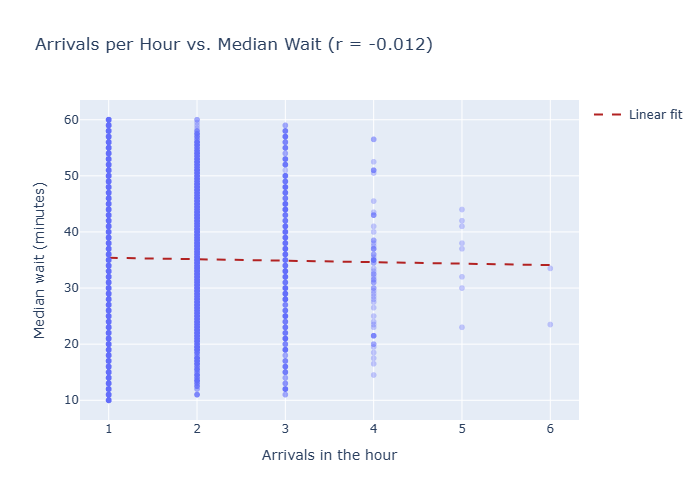

In [3]:
import numpy as np

x = hourly["arrivals"].to_numpy(dtype=float)
y = hourly["median_wait_minutes"].to_numpy(dtype=float)
slope, intercept = np.polyfit(x, y, 1)

fig = px.scatter(hourly, x="arrivals", y="median_wait_minutes", opacity=0.35,
                  title=f"Arrivals per Hour vs. Median Wait (r = {corr:.3f})")
xs = np.linspace(x.min(), x.max(), 50)
fig.add_trace(go.Scatter(x=xs, y=slope * xs + intercept, mode="lines",
                          name="Linear fit", line={"color": "firebrick", "dash": "dash"}))
fig.update_layout(xaxis_title="Arrivals in the hour", yaxis_title="Median wait (minutes)")
fig.show()


The correlation is essentially zero (r ≈ -0.01), and the fitted line is flat. Hourly arrival volume in
this dataset never rises high enough (max 6 patients in a single hour, mean 1.36) to visibly stress
capacity -- there is no point in this scatter where wait times start climbing with load.

> **Business decision this supports:** this data does not identify a volume threshold to staff against.
> A staffing rule of the form "add coverage once hourly arrivals exceed N" cannot be derived from this
> relationship because no such inflection point exists in the observed range.


### Quintile breakdown


In [4]:
q = metrics.load_vs_wait_quintiles(con)
q


,arrivals_quintile,min_arrivals,max_arrivals,avg_arrivals,avg_median_wait,n_hours
0,1,1,1,1.000000,34.497781,1352
1,2,1,1,1.000000,35.338018,1352
2,3,1,1,1.000000,35.951147,1351
3,4,1,2,1.450037,35.539600,1351
4,5,2,6,2.370096,35.178016,1351


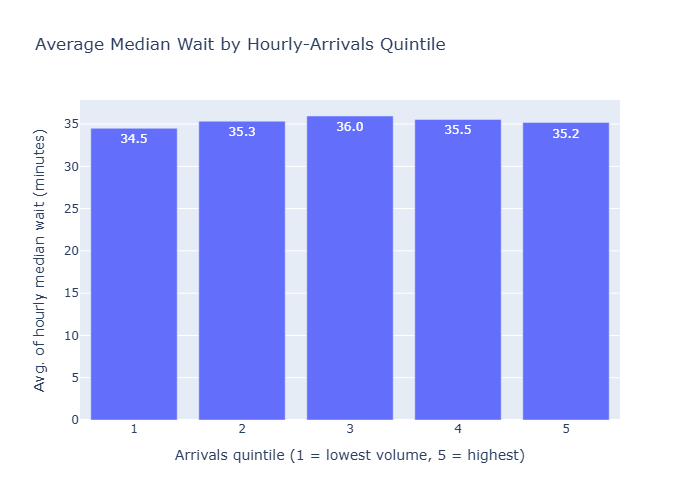

In [5]:
fig = px.bar(q, x="arrivals_quintile", y="avg_median_wait", text=q["avg_median_wait"].map(lambda v: f"{v:.1f}"),
             title="Average Median Wait by Hourly-Arrivals Quintile")
fig.update_layout(xaxis_title="Arrivals quintile (1 = lowest volume, 5 = highest)",
                   yaxis_title="Avg. of hourly median wait (minutes)")
fig.show()


Average wait is essentially flat across all five quintiles (roughly 34.5-36.0 minutes), including the
highest-volume quintile. This confirms the scatter plot's conclusion with a method that is robust to a
handful of outlier hours: there is no quintile at which wait times are visibly worse.

> **Business decision this supports:** confirms that observed wait times are driven by something other
> than concurrent hourly patient volume -- most plausibly a largely fixed per-visit process time in this
> dataset, or factors this warehouse does not capture (staffing, triage acuity mix). Capacity-based
> staffing interventions should not be prioritized on the strength of this analysis alone.


## Executive Summary

There is no detectable relationship between hourly arrival volume and wait time in this data (Pearson
r ≈ -0.01; flat average wait across all five volume quintiles). The observed hourly arrival range (1-6
patients) may simply never reach a level that would stress this department's capacity, or wait times
here are driven by factors this analysis cannot see.

## Business Recommendations

- Do not use hourly arrival volume as a trigger for flexible/surge staffing based on this analysis --
  the data provides no evidence that it would help.
- Investigate the ~35-minute typical wait (from notebook 02) through a process lens (triage speed,
  provider availability, documentation overhead) rather than a capacity lens, since volume does not
  appear to be the driver here.
- If real staffing and census data becomes available, re-run this analysis against it; the absence of a
  load effect in this dataset should not be treated as proof that load never matters operationally.

## Limitations

- No staffing or capacity data exists in this warehouse (`docs/limitations.md`) -- this analysis infers
  the *absence* of a capacity ceiling from behavior, but cannot explain *why* one isn't visible.
- Purely descriptive/correlational; even a nonzero correlation here would not have established
  causation, and time-of-day is a potential unobserved confounder.
- The narrow observed range of hourly arrivals (max 6) may not represent genuine surge conditions; the
  finding "no relationship in this range" is not the same as "no relationship at any volume."

## Next Steps

`04_spc.ipynb` asks a related but distinct question: is the wait-time process stable over time, or is
it drifting, independent of what's driving its level?
